# islide — M1 interactive demo

The canvas-based viewer. `islide.SlideViewer` is a custom Jupyter widget:
Python owns the slide (open, level selection, one-read-per-viewport, tile
cache, JPEG encode); the JS `SlideView` owns the canvas, the pan/zoom
transform, and the mouse. The minimap, zoom/fit/1:1 toolbar, and the
`status` line are part of the view.

> **Note:** the interactive canvas requires the JupyterLab/notebook
> extension (`frontend/`) to be built and installed. In environments
> without it the cells below still run (open + render happen in the
> kernel) but draw no canvas.

In [1]:
from pathlib import Path

from islide import SlideViewer

# Locate the test slide whether the kernel cwd is the repo root or examples/.
slide = next(
    (p for base in (Path.cwd(), Path.cwd().parent)
     for p in [base / "data" / "testslide.tiff"]
     if p.exists()),
    None,
)
assert slide, "data/testslide.tiff not found"

v = SlideViewer(str(slide))
v

SlideViewer(status='opening slide…')

The slide opens on a **background thread** (the kernel stays responsive).
Block until it's ready, then inspect the synced metadata:

In [2]:
v.wait()
v.meta

{'dimensions': [37382, 73222],
 'level_count': 8,
 'level_downsamples': [1.0,
  2.0000808194891597,
  4.000808339273075,
  8.00355764617779,
  16.01229444470048,
  32.04532773883539,
  64.1737892766654,
  128.68154869933454],
 'level_dimensions': [[37382, 73222],
  [18690, 36610],
  [9343, 18303],
  [4670, 9150],
  [2334, 4574],
  [1166, 2286],
  [582, 1142],
  [290, 570]],
 'mpp': 0.25,
 'vendor': 'generic-tiff'}

Navigate with the mouse: **scroll** to zoom at the cursor, **drag** to
pan, or use the **minimap** and the `fit / 1:1` toolbar. Pan/zoom is
applied instantly in the view
(local transform) and the new viewport is synced back to Python (debounced),
which then fetches any missing tiles.

## Programmatic control

The same API drives the view from Python. These update the `viewport`
trait; the view re-centers on the next sync.

In [3]:
v.center_on(18691, 36611)   # middle of the slide
v.set_zoom(2.0)

Viewport(cx=18691.0, cy=36611.0, zoom=2.0, canvas_w=960, canvas_h=540)

In [4]:
# What's on screen right now (level-0 px)?
bbox = v.viewport_bbox()
bbox

(18451.0, 36476.0, 18931.0, 36746.0)

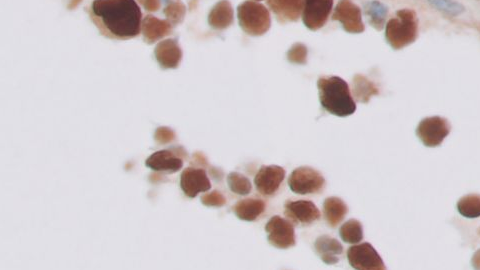

In [5]:
# Programmatic reading of the current view (feeds M2 rubber-band / last_region):
crop = v.read_crop(bbox)
crop

## Tiles & geometry

`v.tiles` maps `"level:tx:ty"` → JPEG data URL; `v.tile_geo` maps the same
key → `[level, ox, oy, cw, ch]` (absolute level-pixel crop origin + size).
The view reprojects this geometry under its local transform, so panning
stays smooth between Python round-trips.

In [6]:
import json
keys = list(v.tiles)
print(f"{len(keys)} tiles for the current viewport")
for k in keys[:4]:
    print(f"  {k}: geo={v.tile_geo[k]}  url_len={len(v.tiles[k])}")

4 tiles for the current viewport
  0:72:142: geo=[0, 18432, 36352, 256, 256]  url_len=11135
  0:73:142: geo=[0, 18688, 36352, 256, 256]  url_len=12511
  0:72:143: geo=[0, 18432, 36608, 256, 256]  url_len=7047
  0:73:143: geo=[0, 18688, 36608, 256, 256]  url_len=8407


## Viewport height

`canvas_h` is a synced trait: the on-screen height of the canvas
viewport (CSS px). Set it at construction (`SlideViewer(path, canvas_h=900)`)
or at runtime — the view applies the new height, its ResizeObserver
syncs the resized viewport back to Python, and Python re-plans the
tiles at the new size.

In [ ]:
v.canvas_h = 800
v.canvas_h

Close (joins the open thread, releases the OpenSlide handle).

In [7]:
v.close()